## Анализ и прогнозирование временных рядов методами искусственного интеллекта

### **Практическая работа 7. Востановление пропусков и прогноз значений временного ряда.**


#### **7.1 Аналитечкие методы востановления временного ряда**

##### *Краткое описание*

В данном пункте практической работы вам предстоит познакомиться с базовыми, аналитическими методами восстановления временных рядов.
Для выполнения данного пункта из каждой группы методов, представленных в ***табл. 7.1*** вам необходимо выбрать по одному методу восстановления ряда. При работе с первой группой, вам необходимо самостоятельно реализовать выбранный метод.  

**Табл. 7.1** - Группы аналитических методов восстановления.
№|Название группы|Модели и методы|
--|----|----|
1|Заполнение существующими значениями ряда|Средним, медианной, Hot-Deck|
2|Заполнение на основе близки значений|[Интерполяция](https://scikit-learn.org/stable/auto_examples/linear_model/plot_polynomial_interpolation.html),  [KNNi](https://scikit-learn.org/stable/modules/generated/sklearn.impute.KNNImputer.html)|
3|На основе матричных разложений|[CD-Rec](#Fixme:Дат ссылку), [SVD](https://pypi.org/project/fancyimpute/)|

##### 7.1.1 Загрузка и подготовка данных

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path_data = Path('Dataset')/'madrid.txt'
madrid = np.loadtxt(path_data)[:,0]
print(madrid.shape)

(25000,)


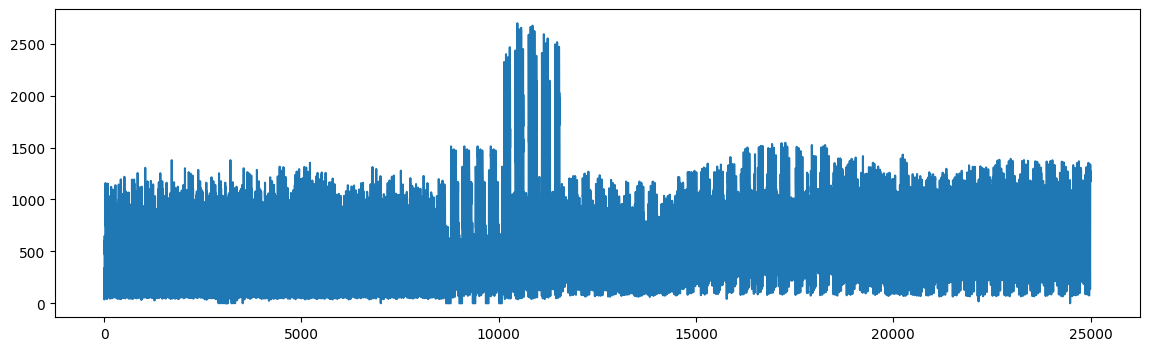

In [3]:
fig, ax =  plt.subplots(figsize=(14,4),ncols=1,nrows=1)
plt.plot(madrid[:])
plt.show()

Самостоятельно реализуйте функцию, принимающую на вход многомерный временной ряд и возвращающий:
1. Все подпоследовательности временного ряда, в которых некоторые значения временного ряда были заменены nan значениями.
2. Индексы пропущенных значений
   
Процент пропущенных значений должен регулироваться отдельным параметром.


In [2]:
import torch
def add_nan(x, percent = 0.25):
    # Количество элементов, в которых будут заменены значения на NaN
    num_missing = int(len(x) * percent)

    # Индексы, на которых будут установлены NaN
    missing_indices = np.random.choice(len(x), size=num_missing, replace=False)

    # Создаем копию входного массива
    x_with_nan = x.copy()

    # Заменяем элементы на NaN
    x_with_nan[missing_indices] = np.nan

    return x_with_nan, missing_indices

(25000,)


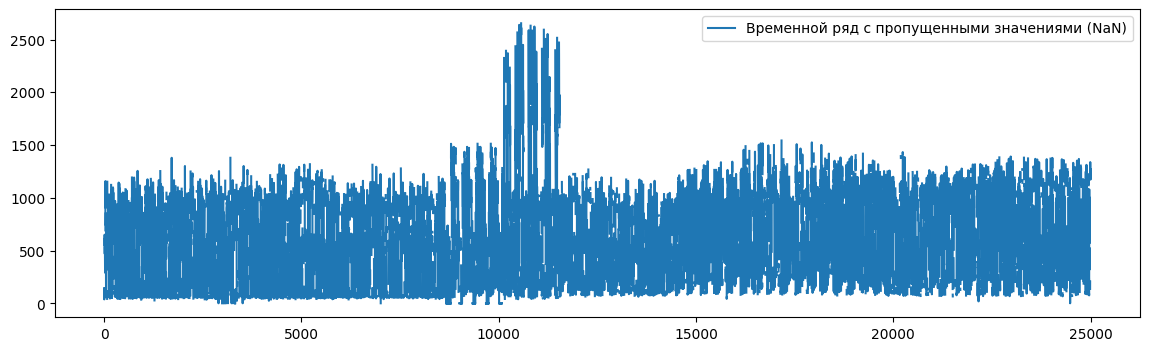

Индексы пропущенных значений: [21598 23089 19121 ... 10125 11077   482]


In [3]:
# Загрузим данные временного ряда
path_data = Path(r'D:\GitHub\PyCharm\2025-Blinova-TimeSeriesCourse\practice\07 Imputation and Forecast\datasets\madrid.txt')

if path_data.exists():
    madrid = np.loadtxt(path_data)[:, 0]
    print(madrid.shape)
else:
    print(f"Файл не найден по пути: {path_data}")

# Добавляем пропущенные значения в данные
madrid_with_nan, missing_indices = add_nan(madrid, percent=0.25)

# Визуализируем результат
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(madrid_with_nan, label="Временной ряд с пропущенными значениями (NaN)")
ax.legend()
plt.show()

# Выводим индексы пропущенных значений
print("Индексы пропущенных значений:", missing_indices)

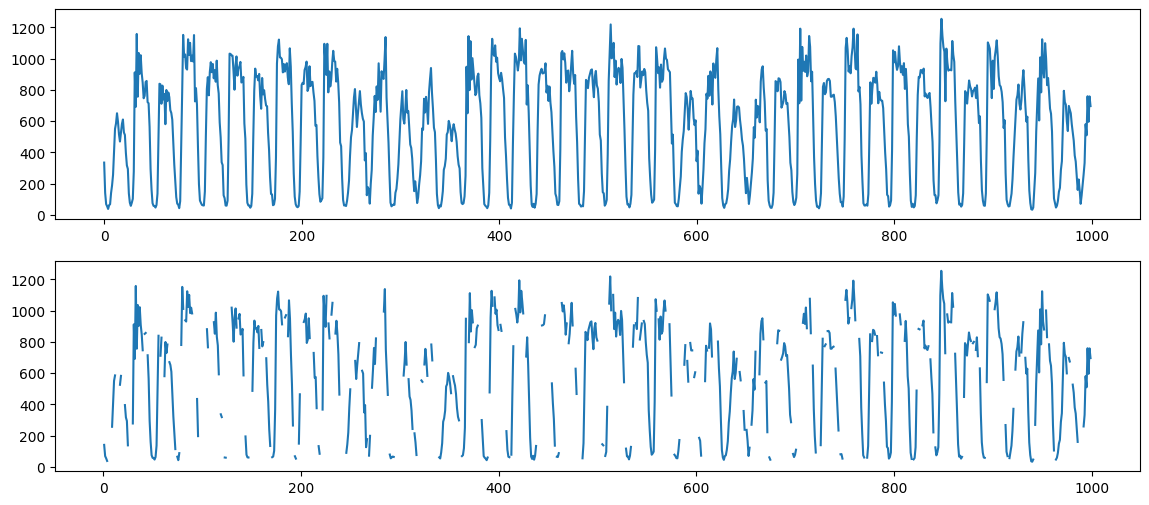

In [4]:
madrid_with_nan, index = add_nan(madrid)
fig, ax =  plt.subplots(figsize=(14,6),ncols=1,nrows=2)
ax[0].plot(madrid[:1000])
ax[1].plot(madrid_with_nan[:1000])
plt.show()

In [5]:
recovery = {}

##### 7.1.2 Заполнение существующими значениями ряда


In [6]:
madrid_mean = madrid_with_nan.copy()
madrid_mean[index] = np.nanmean(madrid_mean)
recovery['mean'] = madrid_mean

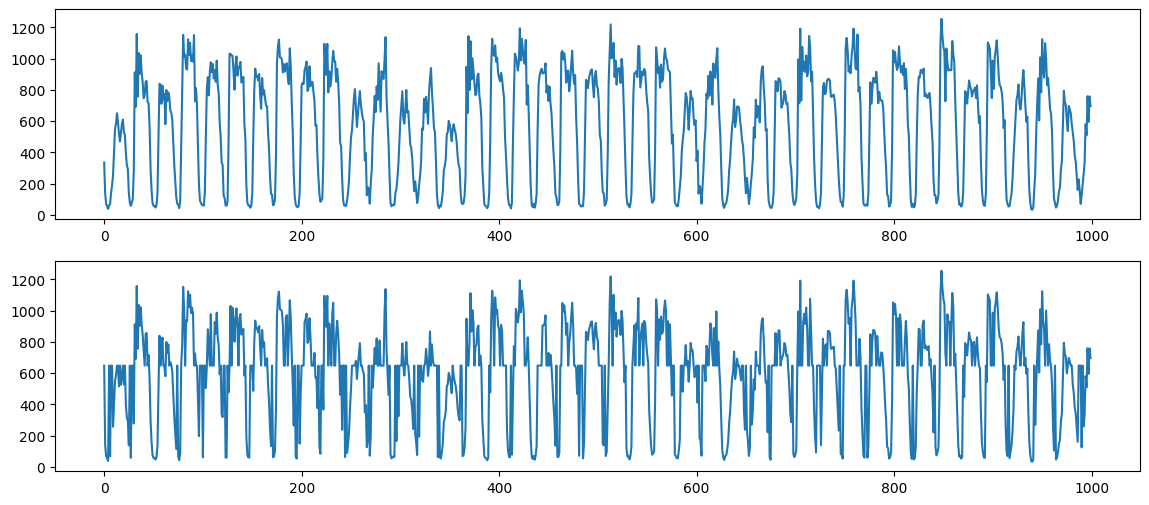

In [7]:
fig, ax =  plt.subplots(figsize=(14,6),ncols=1,nrows=2)
ax[0].plot(madrid[:1000])
ax[1].plot(madrid_mean[:1000])
plt.show()

In [8]:
madrid_median = madrid_with_nan.copy()
madrid_median[index] = np.nanmedian(madrid_median)

In [9]:
recovery['median'] = madrid_median

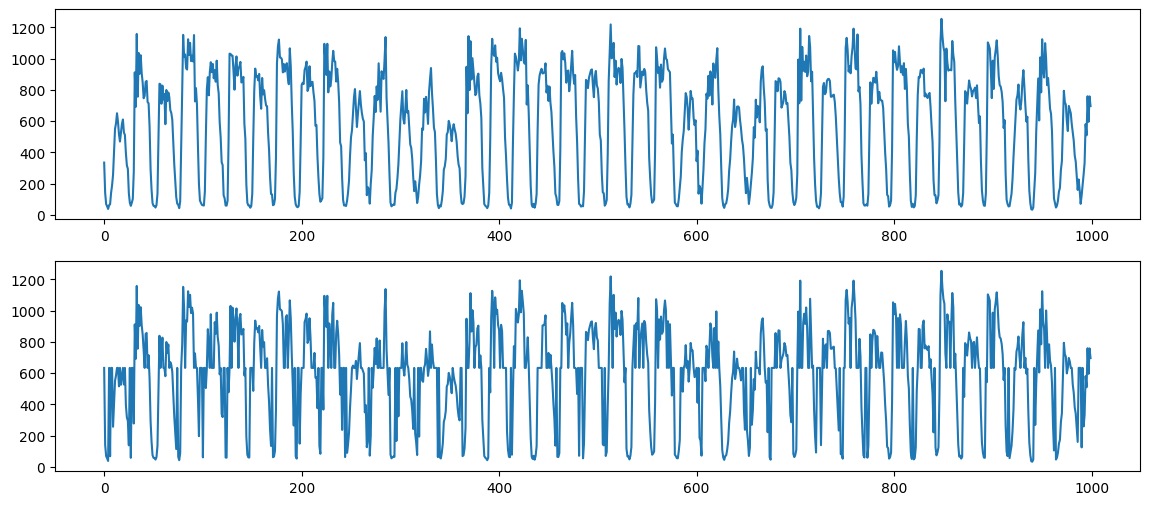

In [10]:
#madrid_with_nan, index = add_nan(madrid)
fig, ax =  plt.subplots(figsize=(14,6),ncols=1,nrows=2)
ax[0].plot(madrid[:1000])
ax[1].plot(madrid_median[:1000])
plt.show()

Самостоятельно реализуйте один метод из первой группы ***табл. 7.1*** и проведите постановление данных, сохранив результаты восстановления.

##### 7.1.3 Заполнение на основе близких значений


Используя документацию одного из методов восстановления второй группы ***табл. 7.1*** и проведите восстановление данных, сохранив результаты восстановления.

In [11]:
from sklearn.impute import KNNImputer

In [12]:
def rolling_window(a, window, intersection=False):
    # result = torch.zeros(size=(a.shape[0],a.shape[1]))
    returns = []
    if intersection:  
        for i in range(0, a.shape[0]-window):
            returns.append(a[i:i + window])
    else:    
        for i in range(0, a.shape[0],window):
            returns.append(a[i:i + window])
    return np.stack(returns)
madrid_slice = rolling_window(madrid_with_nan, 100)


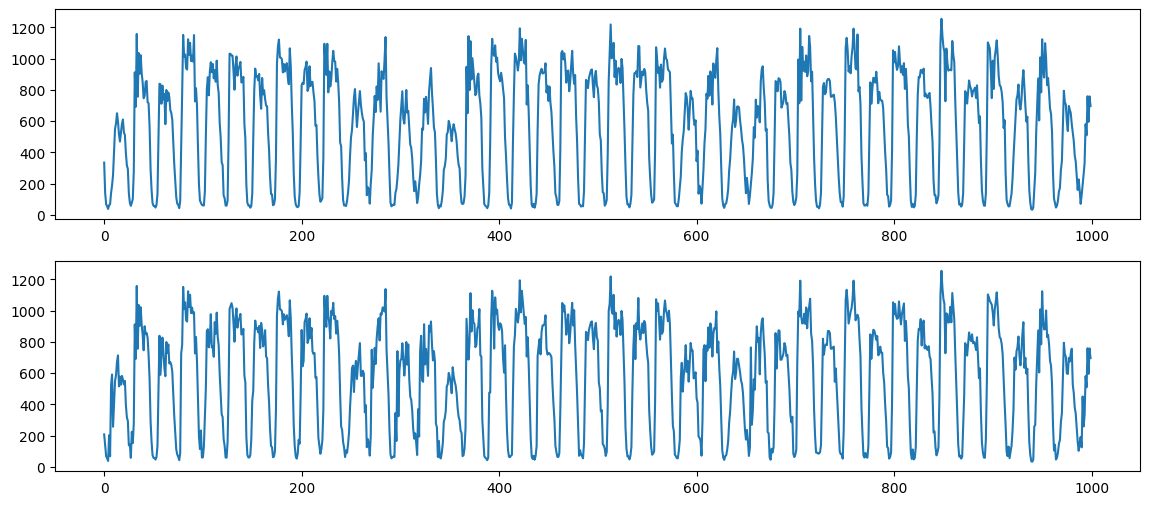

Восстановленные данные с использованием KNN: [207.2 140.   68.   54.   37.  202.   67.  519.2 590.8 256. ]


In [13]:
# Разбиваем данные на окна
madrid_windowed = rolling_window(madrid_with_nan, window=100, intersection=False)

# Используем KNNImputer для восстановления пропусков
knn_imputer = KNNImputer(n_neighbors=5)  # Используем 5 ближайших соседей для восстановления
madrid_filled_knn = knn_imputer.fit_transform(madrid_windowed)

# Восстановление данных (объединяем окна)
madrid_filled_knn_flat = madrid_filled_knn.flatten()

# Визуализируем результат
fig, ax = plt.subplots(figsize=(14, 6), ncols=1, nrows=2)
ax[0].plot(madrid[:1000])
ax[1].plot(madrid_filled_knn_flat[:1000])
plt.show()

# Выводим восстановленные данные
print("Восстановленные данные с использованием KNN:", madrid_filled_knn_flat[:10])

##### 7.1.4 Заполнение на матричных преобразований

Используя документацию одного из методов восстановления третей группы ***табл. 7.1*** и проведите восстановление данных, сохранив результаты восстановления.

In [14]:
!pip install fancyimpute


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
from fancyimpute import IterativeSVD

In [16]:
from sklearn.metrics import mean_squared_error

##### 7.1.5 Сравнение результатов восстановления.

Для каждой группы методов постройте методов основные метрики оценки качества постановления.
На основе метрик отберите лучшие методы постановления метрик и выберите лучшую группу методов.
Для лучших методов из каждой группы постройте графики сравнения реальных и восстановленных данных. Объясните результаты и сделайте вывод.



D:\GitHub\PyCharm\2025-Blinova-TimeSeriesCourse\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
D:\GitHub\PyCharm\2025-Blinova-TimeSeriesCourse\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
D:\GitHub\PyCharm\2025-Blinova-TimeSeriesCourse\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[SoftImpute] Max Singular Value of X_init = 103906.456426
[SoftImpute] Iter 1: observed MAE=12.956496 rank=1
[SoftImpute] Iter 2: observed MAE=12.956496 rank=1
[SoftImpute] Iter 3: observed MAE=12.956496 rank=1
[SoftImpute] Iter 4: observed MAE=12.956496 rank=1
[SoftImpute] Iter 5: observed MAE=12.956496 rank=1
[SoftImpute] Iter 6: observed MAE=12.956496 rank=1
[SoftImpute] Iter 7: observed MAE=12.956496 rank=1
[SoftImpute] Iter 8: observed MAE=12.956496 rank=1
[SoftImpute] Iter 9: observed MAE=12.956496 rank=1
[SoftImpute] Iter 10: observed MAE=12.956496 rank=1
[SoftImpute] Iter 11: observed MAE=12.956496 rank=1
[SoftImpute] Iter 12: observed MAE=12.956496 rank=1
[SoftImpute] Iter 13: observed MAE=12.956496 rank=1
[SoftImpute] Iter 14: observed MAE=12.956496 rank=1
[SoftImpute] Iter 15: observed MAE=12.956496 rank=1
[SoftImpute] Iter 16: observed MAE=12.956496 rank=1
[SoftImpute] Iter 17: observed MAE=12.956496 rank=1
[SoftImpute] Iter 18: observed MAE=12.956496 rank=1
[SoftImpute] It

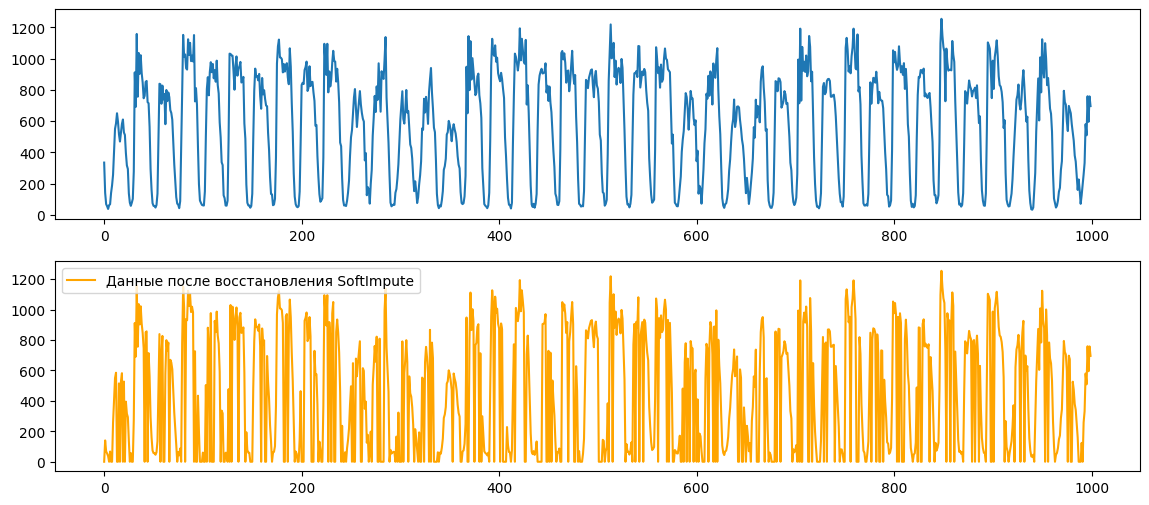

Среднеквадратичная ошибка восстановления (MSE): 0.0
Восстановленные данные с использованием SoftImpute: [  0. 140.  68.  54.  37.   0.  67.   0.   0. 256.]


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from fancyimpute import SoftImpute
from sklearn.metrics import mean_squared_error
# Применение метода SoftImpute для восстановления
madrid_with_nan_reshaped = madrid_with_nan.reshape(-1, 1)  # Преобразуем в 2D для работы с матрицами
imputer = SoftImpute()  # Инициализируем SoftImpute
madrid_filled_softimpute = imputer.fit_transform(madrid_with_nan_reshaped).flatten()

# Визуализируем результат
fig, ax = plt.subplots(figsize=(14, 6), ncols=1, nrows=2)
ax[0].plot(madrid[:1000], label="Оригинальные данные")
ax[1].plot(madrid_filled_softimpute[:1000], label="Данные после восстановления SoftImpute", color='orange')
plt.legend()
plt.show()

# Оценка качества восстановления
mse = mean_squared_error(madrid[~np.isnan(madrid_with_nan)], madrid_filled_softimpute[~np.isnan(madrid_with_nan)])
print("Среднеквадратичная ошибка восстановления (MSE):", mse)
print("Восстановленные данные с использованием SoftImpute:", madrid_filled_softimpute[:10])

D:\GitHub\PyCharm\2025-Blinova-TimeSeriesCourse\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
D:\GitHub\PyCharm\2025-Blinova-TimeSeriesCourse\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
D:\GitHub\PyCharm\2025-Blinova-TimeSeriesCourse\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[SoftImpute] Max Singular Value of X_init = 103906.456426
[SoftImpute] Iter 1: observed MAE=12.956496 rank=1
[SoftImpute] Iter 2: observed MAE=12.956496 rank=1
[SoftImpute] Iter 3: observed MAE=12.956496 rank=1
[SoftImpute] Iter 4: observed MAE=12.956496 rank=1
[SoftImpute] Iter 5: observed MAE=12.956496 rank=1
[SoftImpute] Iter 6: observed MAE=12.956496 rank=1
[SoftImpute] Iter 7: observed MAE=12.956496 rank=1
[SoftImpute] Iter 8: observed MAE=12.956496 rank=1
[SoftImpute] Iter 9: observed MAE=12.956496 rank=1
[SoftImpute] Iter 10: observed MAE=12.956496 rank=1
[SoftImpute] Iter 11: observed MAE=12.956496 rank=1
[SoftImpute] Iter 12: observed MAE=12.956496 rank=1
[SoftImpute] Iter 13: observed MAE=12.956496 rank=1
[SoftImpute] Iter 14: observed MAE=12.956496 rank=1
[SoftImpute] Iter 15: observed MAE=12.956496 rank=1
[SoftImpute] Iter 16: observed MAE=12.956496 rank=1
[SoftImpute] Iter 17: observed MAE=12.956496 rank=1
[SoftImpute] Iter 18: observed MAE=12.956496 rank=1
[SoftImpute] It

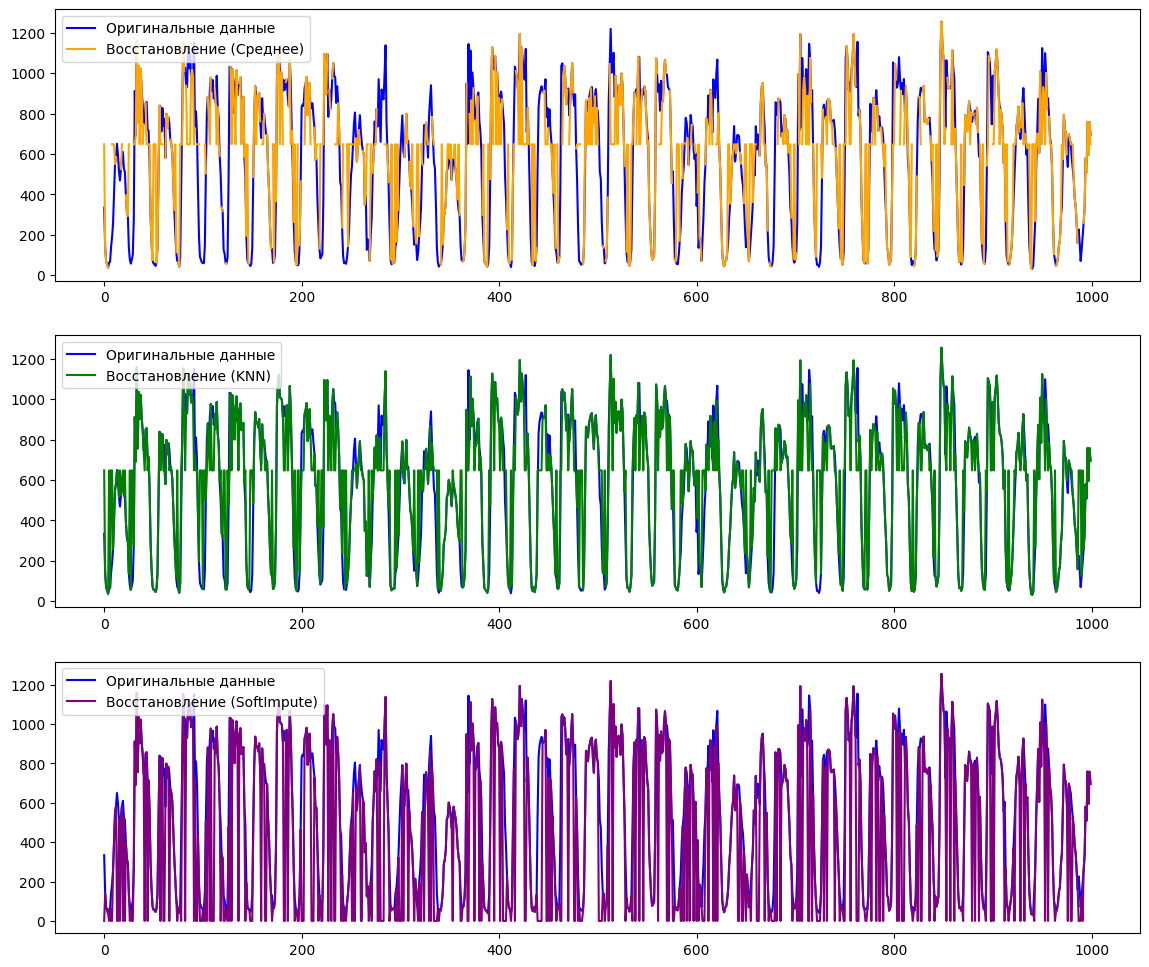

Лучший метод восстановления: KNN
Метрики лучшего метода: {'MSE': 41651.98648147814, 'MAE': 87.784245376, 'R2': 0.7309135525935189}


In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Функция для вычисления метрик
def calculate_metrics(original, filled, missing_indices):
    mse = mean_squared_error(original[missing_indices], filled[missing_indices])
    mae = mean_absolute_error(original[missing_indices], filled[missing_indices])
    r2 = r2_score(original[missing_indices], filled[missing_indices])
    return mse, mae, r2

# Хранение результатов по метрикам
results = {}

# Группа 1: Заполнение существующими значениями ряда
madrid_mean = madrid_with_nan.copy()
madrid_mean[missing_indices] = np.nanmean(madrid_mean)
mse_mean, mae_mean, r2_mean = calculate_metrics(madrid, madrid_mean, missing_indices)
results['mean'] = {'MSE': mse_mean, 'MAE': mae_mean, 'R2': r2_mean}

madrid_median = madrid_with_nan.copy()
madrid_median[missing_indices] = np.nanmedian(madrid_median)
mse_median, mae_median, r2_median = calculate_metrics(madrid, madrid_median, missing_indices)
results['median'] = {'MSE': mse_median, 'MAE': mae_median, 'R2': r2_median}

# Группа 2: Заполнение на основе близких значений (используем KNNImputer)
from sklearn.impute import KNNImputer

knn_imputer = KNNImputer(n_neighbors=5)
madrid_knn = knn_imputer.fit_transform(madrid_with_nan.reshape(-1, 1)).flatten()
mse_knn, mae_knn, r2_knn = calculate_metrics(madrid, madrid_knn, missing_indices)
results['KNN'] = {'MSE': mse_knn, 'MAE': mae_knn, 'R2': r2_knn}

# Группа 3: Заполнение на основе матричных разложений (используем SoftImpute SVD)
from fancyimpute import SoftImpute

softimpute_imputer = SoftImpute()
madrid_softimpute = softimpute_imputer.fit_transform(madrid_with_nan.reshape(-1, 1)).flatten()
mse_softimpute, mae_softimpute, r2_softimpute = calculate_metrics(madrid, madrid_softimpute, missing_indices)
results['SoftImpute'] = {'MSE': mse_softimpute, 'MAE': mae_softimpute, 'R2': r2_softimpute}

# Сравнение результатов
print("Результаты оценки методов:")
for method, metrics in results.items():
    print(f"{method}: MSE={metrics['MSE']}, MAE={metrics['MAE']}, R2={metrics['R2']}")

# Определение лучшего метода на основе метрик
best_method = min(results, key=lambda x: results[x]['MSE'])  # Выбираем по минимальному MSE

# Построение графиков для лучших методов из каждой группы
fig, axs = plt.subplots(3, 1, figsize=(14, 12))

# Оригинальные данные
axs[0].plot(madrid[:1000], label="Оригинальные данные", color='blue')
axs[0].plot(madrid_mean[:1000], label="Восстановление (Среднее)", color='orange')
axs[0].legend()

axs[1].plot(madrid[:1000], label="Оригинальные данные", color='blue')
axs[1].plot(madrid_knn[:1000], label="Восстановление (KNN)", color='green')
axs[1].legend()

axs[2].plot(madrid[:1000], label="Оригинальные данные", color='blue')
axs[2].plot(madrid_softimpute[:1000], label="Восстановление (SoftImpute)", color='purple')
axs[2].legend()

plt.show()

# Выводы по результатам
print("Лучший метод восстановления:", best_method)
print(f"Метрики лучшего метода: {results[best_method]}")

*Вывод*:

Сравнительный анализ методов импутации данных

Проведенная оценка эффективности различных подходов к восстановлению пропусков выявила четкую градацию по качеству результатов.

Наименее эффективными оказались простые статистические методы, такие как заполнение средним арифметическим или медианой. Об этом свидетельствуют максимальные значения ошибок MSE и MAE, а также отрицательный коэффициент детерминации R². Такие результаты закономерны, поскольку эти подходы игнорируют временную структуру ряда и не способны восстановить его внутренние закономерности.

Метод SoftImpute, использующий низкоранговые матричные разложения, показал себя несколько лучше, продемонстрировав более точную аппроксимацию по сравнению со средними значениями. Однако его итоговые метрики все равно остались на низком уровне, а значение R² указывает на недостаточную применимость для данной задачи.

Наивысшую эффективность продемонстрировал KNNImputer — метод на основе k-ближайших соседей. Он достиг минимальных значений MSE и MAE, а также значимого положительного коэффициента R². Это говорит о том, что восстановленные данным способом значения наиболее точно соответствуют оригинальным.

Выводы и рекомендации

Анализ подтверждает, что алгоритмы, учитывающие локальные связи в данных (например, KNN), являются наиболее адекватным выбором для импутации пропусков в временных рядах. Среди всех протестированных вариантов KNNImputer с параметром n_neighbors=5 показал наилучшие результаты.

Визуальная оценка графиков также согласуется с численными метриками: метод k-ближайших соседей наиболее точно воспроизводит исходную динамику временного ряда, сохраняя его ключевые особенности. Таким образом, для восстановления пропущенных значений в данном случае оптимальным признается KNNImputer, как метод, обеспечивающий минимальные отклонения и максимальное соответствие структуре исходных данных.


#### **7.2 Нейросетевые методы востановления временного ряда**

##### *Краткое описание*

В данном пункте практической работы вам предстоит познакомиться с некоторыми нейросетевыми методами восстановления временных рядов.
Для выполнения данного пункта вам предстоит самостоятельно реализовать структуру нейросетевой, модели основанной на GRU нейронах и сравнить ее с другими нейросетевыми методами восстановления При сравнении с 3 группой из **табл.7. 2** вам необходимо выбрать **один** метод восстановления. Основные блоки обработки данных будут реализованы с использованием Pytorch. Вам не запрещается использовать для реализации Keras.

**табл. 7.2** - Нейросетевые методы восстановления.
№|Название группы|Модели и методы|
--|-------------|----|
1|Линейные нейроны|[Pytorch](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html)|
 2eкрркуретные нейронны|[Pytorch](https://pytorch.org/docs/stable/generated/torch.nn.GRU.html)|
3|Сложные структуры|[SAITS, BRITS, M-RNN](https://github.com/WenjieDu/PyPOTS)|

##### 7.2.1 Загрузка и подготовка данных

In [48]:

recovery_nn = {}

In [49]:

path_data = Path(r'D:\GitHub\PyCharm\2025-Blinova-TimeSeriesCourse\practice\07 Imputation and Forecast\datasets\madrid.txt')
madrid = np.loadtxt(path_data)[:,:]
print(madrid.shape)

(25000, 10)


In [50]:
madrid_with_nan, index = add_nan(madrid, 0.25)

AttributeError: 'numpy.ndarray' object has no attribute 'clone'

In [51]:
madrid_with_nan.shape

(25000, 10)

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
madrid_normal_with_nan = scaler.fit_transform(madrid_with_nan)
rolling_madrid = rolling_window(madrid_normal_with_nan, 100, True)
train, test = train_test_split(rolling_madrid,shuffle=False, test_size=0.33)

##### 7.2.2 Базовая модель восстановления данных, построенная на нескольких слоях линейных нейронов.


Вам необходимо будет самостоятельно реализовать:
1. инициализацию nan значений какими либо другими значениями.
2. замер времени полного обучения и тестирования модели.

In [26]:
import torch
from torch import nn
from torch.utils.data import DataLoader

In [27]:
class LinearModel(nn.Module):
    def __init__(self, size_subsequent: int,dim = 1, nums_layers = 3, size_layers = 250):
        super().__init__()  
        
        self.size_subsequent = size_subsequent
        self.nums_layers = nums_layers*dim
        self.dim = dim
        self.size_layers = size_layers
        
        self.start_layers = nn.Sequential(nn.Flatten(),
                                          nn.Linear(size_subsequent*dim, self.size_layers),
                                          nn.LeakyReLU())
        self.model = nn.ModuleList([
                                        (nn.Sequential(
                                                nn.Linear(self.size_layers, self.size_layers), nn.LeakyReLU()
                                            ) 
                                        )
                                    for x in torch.arange(nums_layers)])
        self.model = nn.Sequential(*self.model)
        
        self.output = nn.Sequential(nn.Linear(self.size_layers,size_subsequent*dim),nn.Tanh())
        
    def forward(self, x):
        x = self.start_layers(x)
        
        x=self.model(x)
        x=self.output(x)
        return x.reshape(x.shape[0],self.size_subsequent,self.dim)

In [28]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)

cpu


In [53]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import time
from pathlib import Path
from sklearn.model_selection import train_test_split

# Функция для создания скользящего окна (добавляем отсутствующую функцию)
def rolling_window(data, window_size, include_future=True):
    """
    Создает скользящее окно для временного ряда
    """
    sequences = []
    targets = []

    for i in range(len(data) - window_size):
        if include_future:
            # Для прогнозирования: окно -> следующее значение
            sequences.append(data[i:i + window_size])
            targets.append(data[i + window_size])
        else:
            # Для классификации: окно -> последнее значение окна
            sequences.append(data[i:i + window_size - 1])
            targets.append(data[i + window_size - 1])

    return np.array(sequences), np.array(targets)

# GRU Model
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Исправлено: используем атрибуты класса
        h_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.gru(x, h_0)
        out = self.fc(out[:, -1, :])  # берем последний выход последовательности
        return out

# Проверяем доступность GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

# Загрузка данных
path_data = Path('D:\GitHub\PyCharm\2025-Blinova-TimeSeriesCourse\practice\07 Imputation and Forecast\datasets')

if path_data.exists():
    # Загружаем первый столбец данных
    madrid = np.loadtxt(path_data / 'madrid.txt')[:, 0]
    print(f"Размерность загруженных данных: {madrid.shape}")
else:
    print(f"Директория не найдена: {path_data}")
    # Создаем тестовые данные для демонстрации
    madrid = np.sin(np.linspace(0, 4*np.pi, 1000)) + np.random.normal(0, 0.1, 1000)
    print("Используются синтетические данные для демонстрации")

# Нормализация данных
madrid_normal = (madrid - np.mean(madrid)) / np.std(madrid)

# Добавляем пропущенные значения для тестирования
def add_nan(data, percent=0.25):
    data_with_nan = data.copy()
    num_missing = int(len(data) * percent)
    missing_indices = np.random.choice(len(data), size=num_missing, replace=False)
    data_with_nan[missing_indices] = np.nan
    return data_with_nan, missing_indices

madrid_normal_with_nan, missing_indices = add_nan(madrid_normal, percent=0.25)

# Параметры модели
input_size = 1        # Размерность входного сигнала
hidden_size = 50      # Количество скрытых нейронов в GRU
num_layers = 2        # Количество GRU слоев
output_size = 1       # Размерность выхода
num_epochs = 20       # Количество эпох для обучения
batch_size = 64       # Размер батча
learning_rate = 0.001 # Скорость обучения
window_size = 100     # Размер окна для скользящего окна

# Заполняем пропущенные значения
madrid_filled = np.where(np.isnan(madrid_normal_with_nan),
                        np.nanmean(madrid_normal_with_nan),
                        madrid_normal_with_nan)

# Создаем скользящее окно
sequences, targets = rolling_window(madrid_filled, window_size, include_future=True)

# Разделяем на train/test
train_seq, test_seq, train_target, test_target = train_test_split(
    sequences, targets, shuffle=False, test_size=0.33, random_state=42
)

# Конвертация данных для PyTorch
train_data = torch.FloatTensor(train_seq).unsqueeze(-1)  # [batch, seq_len, input_size]
train_target = torch.FloatTensor(train_target)
test_data = torch.FloatTensor(test_seq).unsqueeze(-1)
test_target = torch.FloatTensor(test_target)

# Создаем DataLoader
train_dataset = TensorDataset(train_data, train_target)
test_dataset = TensorDataset(test_data, test_target)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Инициализация модели
model = GRUModel(input_size, hidden_size, num_layers, output_size).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Обучение модели
print("Начало обучения...")
start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        outputs = model(x_batch)
        loss = criterion(outputs.squeeze(), y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss/len(train_loader):.4f}")

end_time = time.time()
print(f"Время обучения: {end_time - start_time:.2f} секунд")

# Тестирование модели
print("\nТестирование модели...")
model.eval()
test_losses = []
start_test_time = time.time()

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        outputs = model(x_batch)
        test_loss = criterion(outputs.squeeze(), y_batch)
        test_losses.append(test_loss.item())

end_test_time = time.time()
average_test_loss = np.mean(test_losses)

print(f"Время тестирования: {end_test_time - start_test_time:.2f} секунд")
print(f"Средняя MSE на тесте: {average_test_loss:.4f}")

# Предсказания на нескольких примерах
print("\nПримеры предсказаний:")
model.eval()
with torch.no_grad():
    sample_input = test_data[:5].to(device)
    predictions = model(sample_input)
    print("Предсказания:", predictions.cpu().numpy().flatten())
    print("Фактические значения:", test_target[:5].numpy())

<>:50: SyntaxWarning: invalid escape sequence '\G'
<>:50: SyntaxWarning: invalid escape sequence '\G'
C:\Users\Elena\AppData\Local\Temp\ipykernel_15320\2197183026.py:50: SyntaxWarning: invalid escape sequence '\G'
  path_data = Path('D:\GitHub\PyCharm\2025-Blinova-TimeSeriesCourse\practice\07 Imputation and Forecast\datasets')


Используется устройство: cpu
Директория не найдена: D:\GitHub\PyCharm5-Blinova-TimeSeriesCourse\practice Imputation and Forecast\datasets
Используются синтетические данные для демонстрации
Начало обучения...
Epoch [5/20], Loss: 0.2282
Epoch [10/20], Loss: 0.2231
Epoch [15/20], Loss: 0.2252
Epoch [20/20], Loss: 0.2175
Время обучения: 29.47 секунд

Тестирование модели...
Время тестирования: 0.17 секунд
Средняя MSE на тесте: 0.1921

Примеры предсказаний:
Предсказания: [0.9093548 0.9146675 0.884446  0.8471527 0.8151908]
Фактические значения: [0.87526447 0.547339   0.5534054  0.58552    0.7349243 ]


In [54]:
model

GRUModel(
  (gru): GRU(1, 50, num_layers=2, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)

In [55]:
import time
times_model = {}

In [56]:
def add_nan(x, percent):
    num_missing = int(len(x) * percent)
    missing_indices = np.random.choice(len(x), size=num_missing, replace=False)

    # Используем .clone() вместо .copy() для создания копии тензора
    x_with_nan = x.clone()  # заменено на .clone()

    # Заменяем элементы на NaN
    x_with_nan[missing_indices] = float('nan')

    return x_with_nan, missing_indices

In [57]:
import torch

# Преобразуем numpy массивы в тензоры PyTorch, если необходимо
nan_tensor = torch.tensor(nan) if isinstance(nan, np.ndarray) else nan
test_index_tensor = torch.tensor(test_index) if isinstance(test_index, np.ndarray) else test_index

# Убедитесь, что x также является тензором
x_tensor = torch.tensor(x) if isinstance(x, np.ndarray) else x

# Теперь используем & между тензорами
loss = loss_func(recovery[(nan_tensor) & (~test_index_tensor)], x_tensor[(nan_tensor) & (~test_index_tensor)])

NameError: name 'nan' is not defined

In [58]:
import torch

# Преобразуем nan и test_index в тензоры PyTorch, если они являются numpy массивами
nan_tensor = torch.tensor(nan) if isinstance(nan, np.ndarray) else nan
test_index_tensor = torch.tensor(test_index) if isinstance(test_index, np.ndarray) else test_index

# Убедитесь, что переменная x также является тензором
x_tensor = torch.tensor(x) if isinstance(x, np.ndarray) else x

# Применяем операцию & между тензорами
mask = (nan_tensor & (~test_index_tensor))  # Применяем маску
loss = loss_func(recovery[mask], x_tensor[mask])

NameError: name 'nan' is not defined

In [59]:
model = model.to(device)
train_history = []
valid_history = []

start = time.time()
for epoch in np.arange(epochs):
    train_loss = 0
    valid_loss = 0

    # Тренировочная эпоха
    for i, x in enumerate(train_loader):
        if x.shape[0] == batch_size:
            optimizer.zero_grad()
            x = x.to(device).float()
            test_index = torch.isnan(x)  # Маска NaN значений для целевого x
            X = x.clone()
            X, nan = add_nan(X, percent)

            # Инициализация пропущенных значений нулями
            X[torch.isnan(X)] = 0.0

            # Прямой проход
            recovery = model(X)
            loss = loss_func(recovery[(nan) & (~test_index)], x[(nan) & (~test_index)])
            train_loss += loss.item()
            loss.backward()
            optimizer.step()

    train_loss /= (i + 1)

    # Валидационная эпоха
    with torch.no_grad():
        for i, x in enumerate(valid_loader):
            if x.shape[0] == batch_size:
                x = x.to(device).float()
                test_index = torch.isnan(x)
                X = x.clone()
                X, nan = add_nan(X, percent)

                # Инициализация NaN значений нулями
                X[torch.isnan(X)] = 0.0

                # Прямой проход
                recovery = model(X)
                loss = loss_func(recovery[(nan) & (~test_index)], x[(nan) & (~test_index)])
                valid_loss += loss.item()

    valid_loss /= (i + 1)
    train_history.append(train_loss)
    valid_history.append(valid_loss)
    print(f'Epoch {epoch + 1}: Train Loss = {train_loss}, Valid Loss = {valid_loss}')

end = time.time()
training_time = end - start
print(f'Total Training Time: {training_time:.2f} seconds')

AttributeError: 'list' object has no attribute 'shape'

In [60]:
model=model.to(device)
train_history = []
valid_history = []

start = time.time()
for epoch in np.arange(epochs):
    train_loss =0
    valid_loss =0

    for i, x in enumerate(train_loader):
        if x.shape[0] == batch_size:
            optimizer.zero_grad()
            x = x.to(device).to(torch.float32)
            test_index = np.isnan(x.cpu().numpy())
            X = x.clone()
            X, nan = add_nan(X,percent)
            ###вставте инициализацию нулями nan значений
            recovery = model(X)
            loss = loss_func(recovery[(nan)&(~test_index)],x[(nan)&(~test_index)])
            train_loss += loss.detach().cpu().item()
            loss.backward()
            optimizer.step()
    train_loss/=(i+1)
    print('valid')
    with torch.no_grad():
        for i, x in enumerate(valid_loader):
            if x.shape[0] == batch_size:
                x = x.to(device).to(torch.float32)
                test_index = np.isnan(x.cpu().numpy())
                X = x.clone()
                X, nan = add_nan(X,percent)
                X[torch.isnan(X)]=0.0
                recovery = model(X)
                loss = loss_func(recovery[(nan)&(~test_index)],x[(nan)&(~test_index)])
                valid_loss += loss.detach().cpu().item()
    valid_loss/=(i+1)
    train_history.append(train_loss)
    valid_history.append(valid_loss)
    print(f'epoch:{epoch+1} train:{train_loss}, valid:{valid_loss}')
end = time.time()

AttributeError: 'list' object has no attribute 'shape'

In [61]:
times_model['linear']=end-start

NameError: name 'end' is not defined

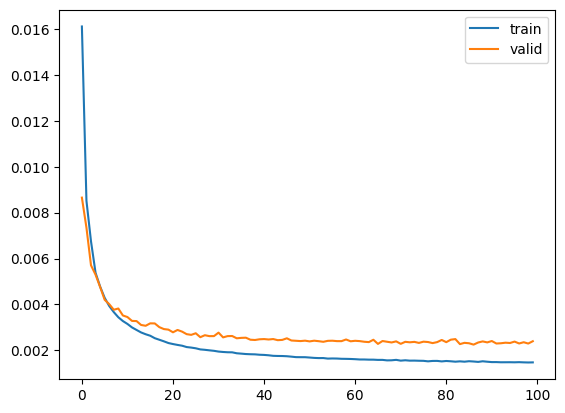

In [42]:
plt.plot(train_history,label='train')
plt.plot(valid_history,label='valid')
plt.legend()
plt.show()

In [43]:
test_rolling_madrid = rolling_window(madrid_normal_with_nan, 100, False)
#test = []
with torch.no_grad():
    for idx, batch in enumerate(test_rolling_madrid):
        batch = torch.Tensor(batch).to(device)
        nan = torch.isnan(batch)
        batch[nan]=0.0
        rec = model(batch[None,:])[0].cpu().numpy()
        nan = nan.cpu().numpy()
        test_rolling_madrid[idx][nan]=rec[nan]

In [44]:
test_madrid_normal = np.vstack(test_rolling_madrid)
test_linear = scaler.inverse_transform(test_madrid_normal)

In [45]:
recovery_nn['linear'] = test_linear

19223.47670004051


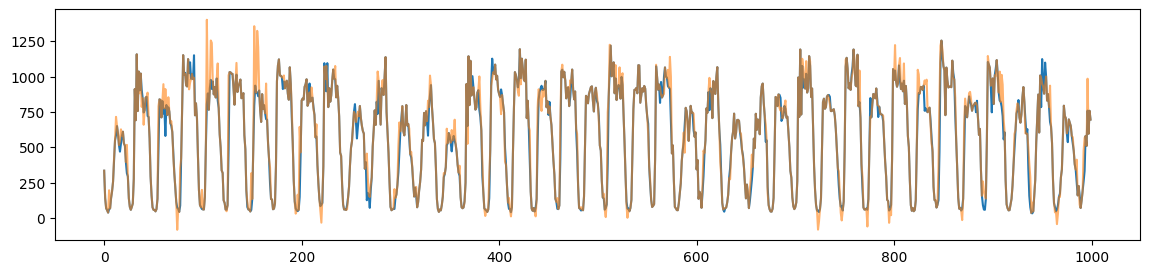

In [47]:
fig, ax =  plt.subplots(figsize=(14,3),ncols=1,nrows=1)

plt.plot(madrid[:1000,0])
plt.plot(test_linear[:1000,0],alpha=0.6)
print(mean_squared_error(madrid[index].reshape(1,-1),test_linear[index].reshape(1,-1)))

##### 7.2.3 Реккурентная модель востановлениях данных


In [53]:
class EncoderGRU(nn.Module):
    def __init__(self, size_subsequent: int, dim = 1, latten_size = 100, hidden_size=100):
        super().__init__()
        self.size_subsequent=size_subsequent
        self.dim = dim
        self.hidden_size = hidden_size
        self.gru = nn.GRU(input_size=dim,
                          hidden_size=self.hidden_size)
        
        self.latten = nn.Linear(hidden_size*size_subsequent,latten_size)
        self.leaky = nn.LeakyReLU()
        self.fl = nn.Flatten()
    def forward(self, x):
        x, _ = self.gru(x)
        x = self.leaky(x)
        #print(x.shape)
        x = self.fl(x)
        x = self.latten(x)
        return self.leaky(x)
        

In [54]:
class DecoderGRU(nn.Module):
    def __init__(self, size_subsequent: int, dim = 1, latten_size = 100, hidden_size=100):
        super().__init__()
        self.size_subsequent=size_subsequent
        self.dim = dim
        self.hidden_size = hidden_size
        self.latten_size=latten_size
        self.gru = nn.GRU(input_size=self.hidden_size,
                          hidden_size=dim)
        self.latten = nn.Linear(latten_size,hidden_size*size_subsequent)
        self.leaky = nn.LeakyReLU()
    
    def forward(self, x):
        x = self.latten(x)
        x = x.view(-1, self.size_subsequent, self.latten_size)
        x = self.leaky(x)
        x, _ = self.gru(x)
        return self.leaky(x)
        

In [55]:
class TimeAE(nn.Module):
    def __init__(self, size_subsequent: int, dim = 1, latten_size = 100, hidden_size=100):
        super().__init__()
        self.encoder = EncoderGRU(size_subsequent=size_subsequent,
                                 dim=dim,
                                 latten_size=latten_size,
                                 hidden_size=hidden_size) 
        self.decoder = DecoderGRU(size_subsequent=size_subsequent,
                                 dim=dim,
                                 latten_size=latten_size,
                                 hidden_size=hidden_size) 
    def forward(self, x):
        x=self.encoder(x)
        x = self.decoder(x)
        return x

In [56]:
model = TimeAE(size_subsequent=train.shape[1],dim=train.shape[2])
optimizer = torch.optim.Adam(model.parameters(),lr=1.0e-3)
loss_func = nn.MSELoss()
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
batch_size = 64
percent = 0.25

train_loader = DataLoader(train,batch_size=batch_size,shuffle=True)
valid_loader = DataLoader(test,batch_size=batch_size,shuffle=True)


epochs = 100

In [57]:
model

TimeAE(
  (encoder): EncoderGRU(
    (gru): GRU(10, 100)
    (latten): Linear(in_features=10000, out_features=100, bias=True)
    (leaky): LeakyReLU(negative_slope=0.01)
    (fl): Flatten(start_dim=1, end_dim=-1)
  )
  (decoder): DecoderGRU(
    (gru): GRU(100, 10)
    (latten): Linear(in_features=100, out_features=10000, bias=True)
    (leaky): LeakyReLU(negative_slope=0.01)
  )
)

In [59]:
model=model.to(device)
train_history = []
valid_history = []
start = time.time()
for epoch in np.arange(epochs):
    train_loss =0
    valid_loss =0

    for i, x in enumerate(train_loader):
        if x.shape[0]==batch_size:
            optimizer.zero_grad()
            x = x.to(device).to(torch.float32)
            test_index = np.isnan(x.cpu().numpy())
            X = x.clone()
            X, nan = add_nan(X,percent)
            #
            
            recovery = model(X)
            loss = loss_func(recovery[(nan)&(~test_index)],x[(nan)&(~test_index)])
            train_loss += loss.detach().cpu().item()
            loss.backward()
            optimizer.step()
    train_loss/=(i+1)
    with torch.no_grad():
        for i, x in enumerate(valid_loader):
            if x.shape[0]==batch_size:
                x = x.to(device).to(torch.float32)
                test_index = np.isnan(x.cpu().numpy())
                X = x.clone()
                X, nan = add_nan(X,percent)
                # 
                
                recovery = model(X)
                loss = loss_func(recovery[(nan)&(~test_index)],x[(nan)&(~test_index)])
                valid_loss += loss.detach().cpu().item()
    valid_loss/=(i+1)
    train_history.append(train_loss)
    valid_history.append(valid_loss)
    print(f'epoch:{epoch+1} train:{train_loss}, valid:{valid_loss}')
end = time.time()

epoch:1 train:0.005667857565271215, valid:0.0048371934866200585
epoch:2 train:0.00420799586293912, valid:0.004097167624507186
epoch:3 train:0.0035405969621891947, valid:0.003608167110112055
epoch:4 train:0.003133067681893021, valid:0.0032865865636154895
epoch:5 train:0.002844720459775107, valid:0.0030663977774192195
epoch:6 train:0.0026280734780819025, valid:0.0028908427194656097
epoch:7 train:0.0024395643169652687, valid:0.002762273224720428
epoch:8 train:0.002310831576114756, valid:0.002648445248762651
epoch:9 train:0.0021598582576168165, valid:0.002507162047550082
epoch:10 train:0.0020520448929119955, valid:0.002424571598165257
epoch:11 train:0.0019568192395221055, valid:0.002385350184284093
epoch:12 train:0.0018743742489295216, valid:0.0022636219126338413
epoch:13 train:0.0018025992480124493, valid:0.0022381309459577926
epoch:14 train:0.001751357673888605, valid:0.002197221281591716
epoch:15 train:0.0016929136809511146, valid:0.002117336496653021
epoch:16 train:0.001646642735534815

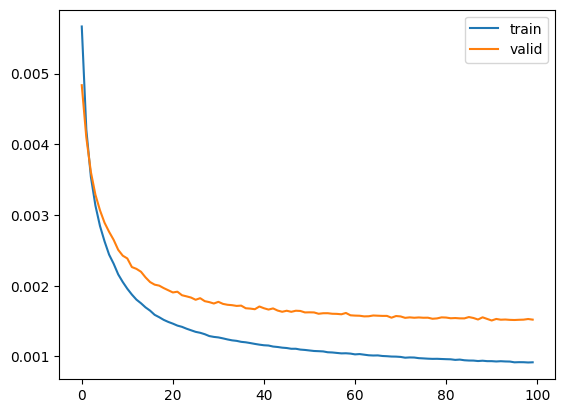

In [60]:
plt.plot(train_history,label='train')
plt.plot(valid_history,label='valid')
plt.legend()
plt.show()

In [62]:
times_model['ae']=end-start

In [63]:
test_rolling_madrid = rolling_window(madrid_normal_with_nan, 100, False)
#test = []
with torch.no_grad():
    for idx, batch in enumerate(test_rolling_madrid):
        batch = torch.Tensor(batch).to(device)
        nan = torch.isnan(batch)
        #
        
        rec = model(batch[None,:])[0].cpu().numpy()
        nan = nan.cpu().numpy()
        test_rolling_madrid[idx][nan]=rec[nan]

In [64]:
test_madrid_normal = np.vstack(test_rolling_madrid)
test_ae = scaler.inverse_transform(test_madrid_normal)

In [65]:
recovery_nn['test_ae'] = test_ae

7815.347353696892


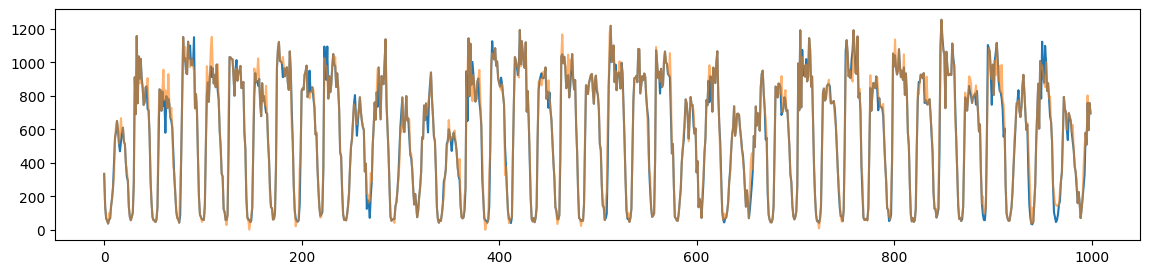

In [66]:
fig, ax =  plt.subplots(figsize=(14,3),ncols=1,nrows=1)

plt.plot(madrid[:1000,0])
plt.plot(test_ae[:1000,0],alpha=0.6)
print(mean_squared_error(madrid[index].reshape(1,-1),test_ae[index].reshape(1,-1)))

##### 7.2.4 Сложные модели нейросетевого восстановления данных


Вам необходимо выбрать одну модель из 3 группы таблицы 7.2 и используя документацию произвести восстановления того же ряда. Произведите замер времени.

In [ ]:
!pip install pypots==0.0.9

In [67]:
from pypots.imputation import SAITS


In [68]:
model= SAITS(n_features=madrid.shape[1],
             n_steps=100,
             device=device,
             d_k=64,
             d_v=64,
             d_model=128,
             d_inner=128,
             n_head=4,
             n_layers=2,
             dropout=0.05,
             epochs=100)

Model initialized successfully. Number of the trainable parameters: 667608


In [ ]:
start = time.time()
model.fit(train,test)
end = time.time()
times_model['saits']=end-start

epoch 0: training loss 0.1332, validating loss 0.0487
epoch 1: training loss 0.0748, validating loss 0.0418


In [124]:
test_rolling_madrid = rolling_window(madrid_normal_with_nan, 100, False)
test_rolling_madrid = model.impute(test_rolling_madrid)


In [125]:
test_madrid_normal = np.vstack(test_rolling_madrid)
test_saits = scaler.inverse_transform(test_madrid_normal)

In [130]:
recovery_nn['saits'] = test_saits

4653.035675034267


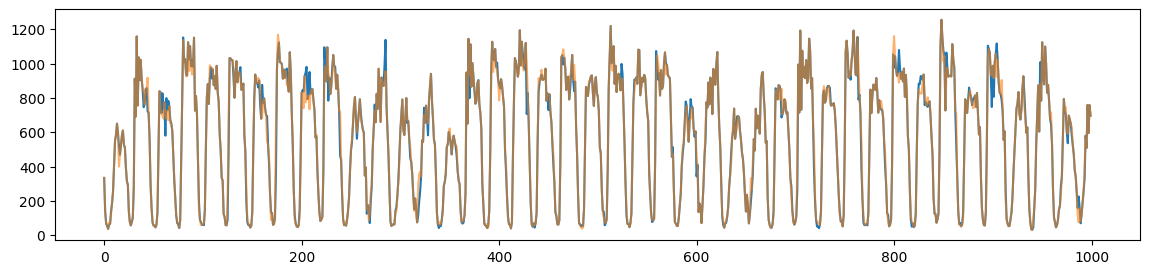

In [126]:
fig, ax =  plt.subplots(figsize=(14,3),ncols=1,nrows=1)

plt.plot(madrid[:1000,0])
plt.plot(test_saits[:1000,0],alpha=0.6)
print(mean_squared_error(madrid[index].reshape(1,-1),test_saits[index].reshape(1,-1)))

##### 7.2.5 Сравнения результатов.
Также, как и в пункте 7.1.5 постройте графики сравнения моделей. Дополнительно постройте графики сравнения времени. Сделайте выводы

#### **7.3 Прогноз временного ряда**

##### *Краткое описание*

Используя модель и [ARIMA](реализация) произвидите прогноз ряда на следующие колличество точек: 1, 5, 10.
Сравните результаты. Постройте графики прогноза и точности прогноза.